In [1]:
import app
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import rasterio
import rasterio.plot as rplt
import rasterio.windows  as rw
from rasterio.transform import Affine
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np

app.setup_logger(use_console_handler=True, use_file_handler=False)
path = r"D:\PhD\21_Experiments\TidesDamageDriver\02_processed\01_drainages_50"
tucket = r"D:\PhD\21_Experiments\TidesDamageDriver\01_raw\L8S2-tucket"
rgb = r"D:\PhD\21_Experiments\TidesDamageDriver\01_raw\L8S2-mosaics"
out_path = r"D:\PhD\21_Experiments\TidesDamageDriver\02_processed\01_drainages_50_plots"
out_path_failed = r"D:\PhD\21_Experiments\TidesDamageDriver\02_processed\01_drainages_50_plots_failed"

if not os.path.exists(out_path):
    os.makedirs(out_path)
if not os.path.exists(out_path_failed):
    os.makedirs(out_path_failed)

In [2]:
def get_bounds(gdf, offset=1e3):
    minx = min(gdf.centroid.x) - offset
    miny = min(gdf.centroid.y) - offset
    maxx = max(gdf.centroid.x) + offset
    maxy = max(gdf.centroid.y) + offset
    return minx, miny, maxx, maxy

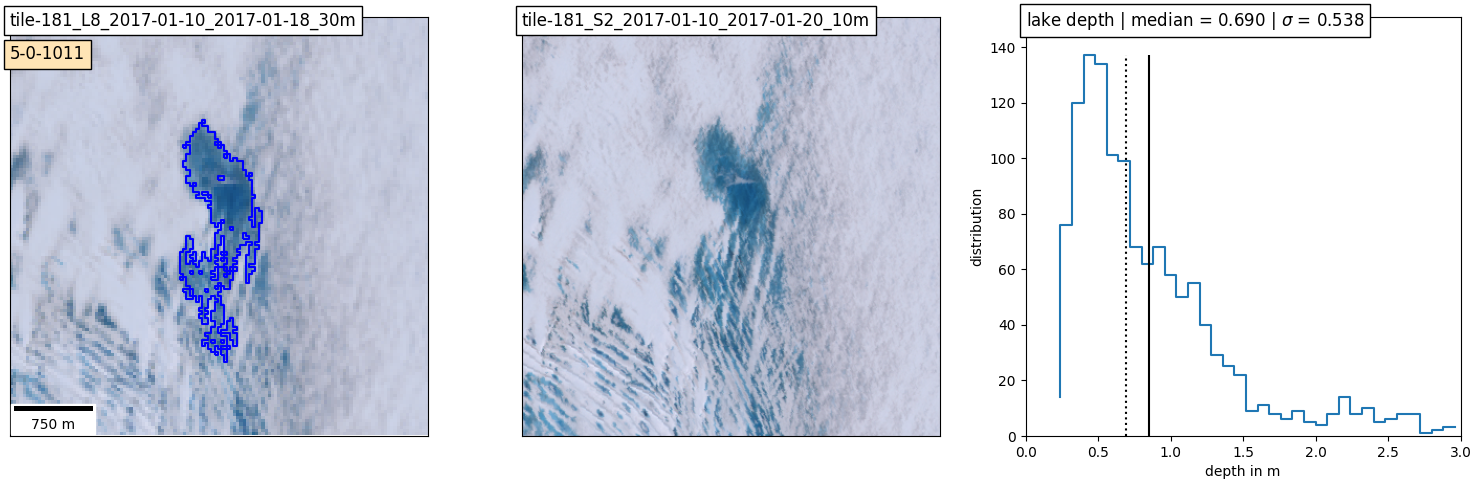

2025-10-07 01:06:16,999 WARNING  matplotlib.image Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1459501..1.024223].
2025-10-07 01:06:17,065 WARNING  matplotlib.image Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1315..1.1077].


KeyboardInterrupt: 

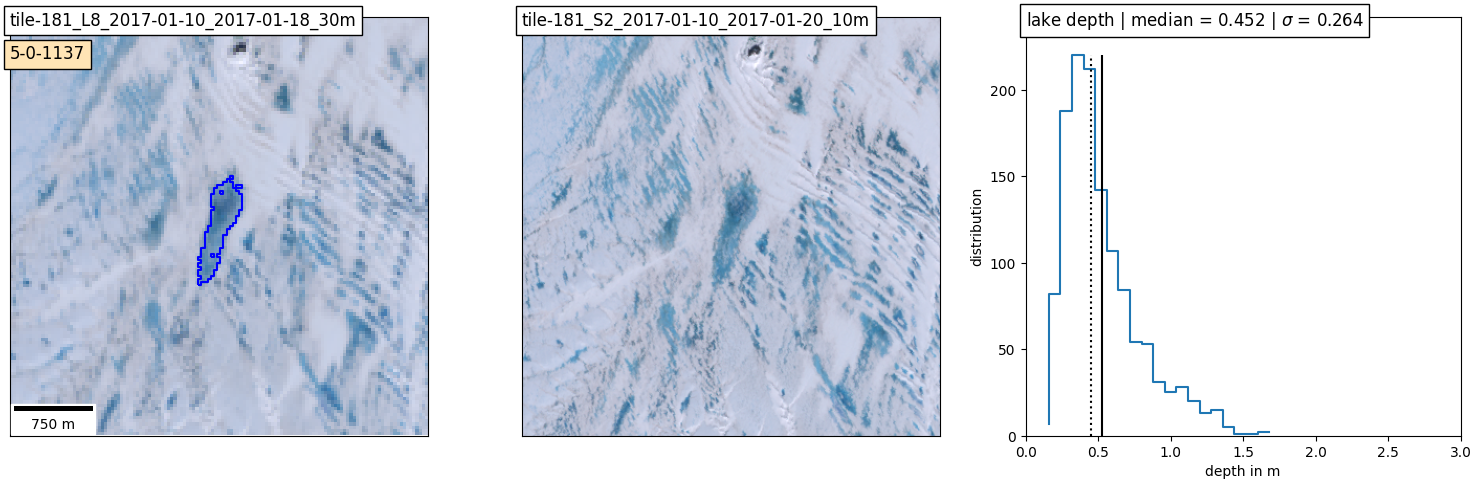

In [3]:
YEARS = ["2016", "2018", "2019", "2020"]
offset = 2e3
max_depth = 3

for year in YEARS:
    year_path = os.path.join(path, str(year))
    year_tucket = os.path.join(tucket, str(year))
    year_rgb = os.path.join(rgb, str(year))
    gdf_0 = app.lakes.plotting.get_geodataframes(year_path, ["_0."])[0]
    gdf_1 = app.lakes.plotting.get_geodataframes(year_path, ["_1."])[0]
    gdf_0_failed = app.lakes.plotting.get_geodataframes(year_path, ["_0_"])[0]
    gdf_1_failed = app.lakes.plotting.get_geodataframes(year_path, ["_1_"])[0]


    for ilake, criteria in enumerate(gdf_0["criteria"].unique()):
        gdf_0_ = gdf_0[gdf_0["criteria"] == criteria]
        gdf_1_ = gdf_1[gdf_1["criteria"] == criteria]
        file_0 = gdf_0_["file_0"].values[0]
        file_1 = gdf_0_["file_1"].values[0]
        file_0_rgb = file_0.replace(".tif", "_rgb.tif")
        file_1_rgb = file_1.replace(".tif", "_rgb.tif")
        label = str(gdf_0_["ifile_0"].values[0]) + "-" + str(gdf_0_["ifile_1"].values[0]) + "-" + str(int(gdf_0_["lake id"].values[0]))

        minx, miny, maxx, maxy = get_bounds(gdf_0_, offset=offset)
        
        with rasterio.open(os.path.join(year_rgb, file_0_rgb)) as src: 
            rgb0 = src.read(window=rw.from_bounds(minx, miny, maxx, maxy, src.transform))
            rgb0_transform = Affine(src.transform[0], 0, minx, 0, src.transform[4], maxy)
        
        with rasterio.open(os.path.join(year_tucket, file_0)) as src: 
            tucket0 = src.read(window=rw.from_bounds(minx, miny, maxx, maxy, src.transform))
            tucket0_transform = Affine(src.transform[0], 0, minx, 0, src.transform[4], maxy)
            depth0 = tucket0[2]
        
        with rasterio.open(os.path.join(year_rgb, file_1_rgb)) as src:
            rgb1 = src.read(window=rw.from_bounds(minx, miny, maxx, maxy, src.transform))
            rgb1_transform = Affine(src.transform[0], 0, minx, 0, src.transform[4], maxy)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Plot first image
        ax = axes[0]
        ax.text(0, 0.98, f"{file_0.replace('.tif', '')}", transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', edgecolor='black'))
        ax.text(0, 0.9, f"{label}", transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='moccasin', edgecolor='black'))
        rplt.show(rgb0, transform=rgb0_transform, ax=ax)
        gdf_0_.boundary.plot(ax=ax, color="blue")
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

        # Remove axis labels and ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")

        # Add scalebar (assumes pixel size = transform[0] in meters/pixel)
        scalebar = ScaleBar(1, units="m", location="lower left")
        ax.add_artist(scalebar)

        # Plot second image
        ax = axes[1]
        ax.text(0, 0.98, f"{file_1.replace('.tif', '')}", transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', edgecolor='black'))
        rplt.show(rgb1, transform=rgb1_transform, ax=ax)
        if not gdf_1_.empty:
            gdf_1_.boundary.plot(ax=ax, color="red")
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

        # Remove axis labels and ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")

        ax = axes[2]
        bins = np.linspace(0, max_depth + 1, 51)
        depth0_digits = np.digitize(depth0, bins = bins)
        uniques, counts = np.unique(depth0_digits, return_counts = True)
        ax.step(uniques[:-1] * np.diff(bins)[0], counts[:-1])
        ax.vlines(x = np.nanmean(depth0), ymin = 0, ymax = counts[:-1].max(), label = "mean", color = "black")
        ax.vlines(x = np.nanmedian(depth0), ymin = 0, ymax = counts[:-1].max(), label = "median", color = "black", ls = ":")
        ax.set_xlabel("depth in m")
        ax.set_ylabel("distribution")
        ax.text(.0, .98, "lake depth" + " | median = " + f"{np.nanmedian(depth0):.3f} | "  + r"$\sigma$ = " + f"{np.nanstd(depth0):.3f}", fontsize=12, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='black'))
        ax.set_xlim(0,max_depth)
        ax.set_ylim(0, counts[:-1].max() * 1.1)

        if not os.path.exists(os.path.join(out_path, str(year))):
            os.makedirs(os.path.join(out_path, str(year)))
            
        plt.tight_layout()
        fig.savefig(os.path.join(out_path, str(year), f"{criteria}.png"), dpi=300)
        plt.show()

        if ilake >= 1000:
            break

In [ ]:
YEARS = ["2016", "2018", "2019", "2020"]
offset = 2e3
max_depth = 3

for year in YEARS:
    year_path = os.path.join(path, str(year))
    year_tucket = os.path.join(tucket, str(year))
    year_rgb = os.path.join(rgb, str(year))
    gdf_0 = app.lakes.plotting.get_geodataframes(year_path, ["_0."])[0]
    gdf_1 = app.lakes.plotting.get_geodataframes(year_path, ["_1."])[0]
    gdf_0_failed = app.lakes.plotting.get_geodataframes(year_path, ["_0_"])[0]
    gdf_1_failed = app.lakes.plotting.get_geodataframes(year_path, ["_1_"])[0]

    
    for ilake, criteria in enumerate(gdf_0_failed["criteria"].unique()):
        gdf_0_failed_ = gdf_0_failed[gdf_0_failed["criteria"] == criteria]
        gdf_1_failed_ = gdf_1_failed[gdf_1_failed["criteria"] == criteria]
        file_0 = gdf_0_failed_["file_0"].values[0]
        file_1 = gdf_0_failed_["file_1"].values[0]
        file_0_rgb = file_0.replace(".tif", "_rgb.tif")
        file_1_rgb = file_1.replace(".tif", "_rgb.tif")
        label = str(gdf_0_failed_["ifile_0"].values[0]) + "-" + str(gdf_0_failed_["ifile_1"].values[0]) + "-" + str(int(gdf_0_failed_["lake id"].values[0]))

        minx, miny, maxx, maxy = get_bounds(gdf_0_failed_, offset=offset)
        
        with rasterio.open(os.path.join(year_rgb, file_0_rgb)) as src: 
            rgb0 = src.read(window=rw.from_bounds(minx, miny, maxx, maxy, src.transform))
            rgb0_transform = Affine(src.transform[0], 0, minx, 0, src.transform[4], maxy)
        
        with rasterio.open(os.path.join(year_tucket, file_0)) as src: 
            tucket0 = src.read(window=rw.from_bounds(minx, miny, maxx, maxy, src.transform))
            tucket0_transform = Affine(src.transform[0], 0, minx, 0, src.transform[4], maxy)
            depth0 = tucket0[2]
        
        with rasterio.open(os.path.join(year_rgb, file_1_rgb)) as src:
            rgb1 = src.read(window=rw.from_bounds(minx, miny, maxx, maxy, src.transform))
            rgb1_transform = Affine(src.transform[0], 0, minx, 0, src.transform[4], maxy)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Plot first image
        ax = axes[0]
        ax.text(0, 0.98, f"{file_0.replace('.tif', '')}", transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', edgecolor='black'))
        ax.text(0, 0.9, f"{label}", transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='moccasin', edgecolor='black'))
        rplt.show(rgb0, transform=rgb0_transform, ax=ax)
        gdf_0_failed_.boundary.plot(ax=ax, color="blue")
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

        # Remove axis labels and ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")

        # Add scalebar (assumes pixel size = transform[0] in meters/pixel)
        scalebar = ScaleBar(1, units="m", location="lower left")
        ax.add_artist(scalebar)

        # Plot second image
        ax = axes[1]
        ax.text(0, 0.98, f"{file_1.replace('.tif', '')}", transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', edgecolor='black'))
        rplt.show(rgb1, transform=rgb1_transform, ax=ax)
        if not gdf_1_failed_.empty:
            gdf_1_failed_.boundary.plot(ax=ax, color="red")
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

        # Remove axis labels and ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")

        ax = axes[2]
        bins = np.linspace(0, max_depth + 1, 51)
        depth0_digits = np.digitize(depth0, bins = bins)
        uniques, counts = np.unique(depth0_digits, return_counts = True)
        ax.step(uniques[:-1] * np.diff(bins)[0], counts[:-1])
        ax.vlines(x = np.nanmean(depth0), ymin = 0, ymax = counts[:-1].max(), label = "mean", color = "black")
        ax.vlines(x = np.nanmedian(depth0), ymin = 0, ymax = counts[:-1].max(), label = "median", color = "black", ls = ":")
        ax.set_xlabel("depth in m")
        ax.set_ylabel("distribution")
        ax.text(.0, .98, "lake depth" + " | median = " + f"{np.nanmedian(depth0):.3f} | "  + r"$\sigma$ = " + f"{np.nanstd(depth0):.3f}", fontsize=12, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='black'))
        ax.set_xlim(0,max_depth)
        ax.set_ylim(0, counts[:-1].max() * 1.1)

        plt.tight_layout()
        fig.savefig(os.path.join(out_path_failed, str(year), f"{criteria}.png"), dpi=300)
        plt.close()

        if ilake >= 10000:
            break

2025-07-09 01:50:52,919 WARNING  matplotlib.image Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3240621..1.1637099].
2025-07-09 01:50:52,994 WARNING  matplotlib.image Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3799..1.3465].
2025-07-09 01:50:53,645 WARNING  matplotlib.image Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3240621..1.1637099].
2025-07-09 01:50:53,712 WARNING  matplotlib.image Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3799..1.3465].
2025-07-09 01:50:54,336 WARNING  matplotlib.image Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.37473986..1.0744603].
2025-07-09 01:50:54,404 WARNING  matplotl